### In this module you will learn:

1. How to classify credit card defaults based on observable characteristics
2. Examine goodness-of-fit measures for classification
3. Explore generalized additive models
4. Explore shrinkage of nonlinear models


### The Data

The credit card default data is from Taiwan in 2005. We don't have too many covariates to examine, but the ones we do have should be informative. Let's look at the raw data to see the names and descriptions:

| Covariate Name | Description                         |
|----------------|-------------------------------------|
| LIMIT_BAL      | Amt of credit available             |
| SEX            | Indicator for sex                   |
| AGE            | Age                                 |
| PAY            | Denotes delinquency in past periods |
| BILL_AMT       | Denotes amount due in past periods  |
| PAY_AMT        | Denotes amount paid in past periods |
| educ           | Indicator for Education Level       |
| marr           | Indicator for marital status        |
| default        | Indicator for default status        |

Alright now that we know what the variable names correspond to, let's load in the data.

In [4]:
import random
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from tqdm import tqdm

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler

random.seed(2718281)
np.random.seed(2718281)

In [5]:
import os
import urllib.request
if not os.path.exists('default.zip'):
    urllib.request.urlretrieve("https://github.com/bquistorff/NABE_workbooks/raw/colab/default.zip", 'default.zip')

In [6]:
with zipfile.ZipFile('default.zip', 'r') as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        defaults = pd.read_csv(f)

print(defaults.iloc[:10, :10].to_string())

print(f'\nDataset dimensions: {defaults.shape}')
# Returns the dimension of the dataset

defaults['default'] = defaults['default'].astype(int)


   LIMIT_BAL  SEX  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1
0      20000    1   24      2      2     -1     -1     -2     -2       3913
1     120000    1   26     -1      2      0      0      0      2       2682
2      90000    1   34      0      0      0      0      0      0      29239
3      50000    1   37      0      0      0      0      0      0      46990
4      50000    0   57     -1      0     -1      0      0      0       8617
5      50000    0   37      0      0      0      0      0      0      64400
6     500000    0   29      0      0      0      0      0      0     367965
7     100000    1   23      0     -1     -1      0      0     -1      11876
8     140000    1   28      0      0      2      0      0      0      11285
9      20000    0   35     -2     -2     -2     -2     -1     -1          0

Dataset dimensions: (30000, 31)


## Validation Split in Discrete Data

One thing we have to be careful about in classification is how we split the sample to preserve the balance of the data. Let's see what proportion of the sample actually defaults.


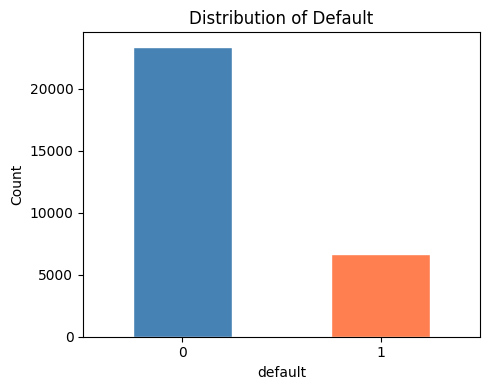

proportion of defaults: 0.2840


In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
defaults['default'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white')
ax.set_xlabel('default')
ax.set_ylabel('Count')
ax.set_title('Distribution of Default')
ax.set_xticklabels(['0', '1'], rotation=0)
plt.tight_layout()
plt.show()

prop = defaults['default'].sum() / (defaults['default'] == 0).sum()
print(f'proportion of defaults: {prop:.4f}')


\
It looks like a bit more than $\frac{1}{4}$ of the sample defaults. As we did before, let's \
split our data into train-test-validation sets, but this time we use `train_test_split` with \
`stratify=defaults['default']`. This automatically balances the splits based on the default \
outcome, equivalent to caret's `createDataPartition`.


In [8]:
# Splitting the data — stratify preserves the default proportion in each split
train_test, validation = train_test_split(
    defaults, test_size=0.1,
    stratify=defaults['default'],
    random_state=2718281
)
print(f'Train-test size: {len(train_test)},  default rate: {train_test["default"].mean():.4f}')
print(f'Validation size: {len(validation)},  default rate: {validation["default"].mean():.4f}')


Train-test size: 27000,  default rate: 0.2212
Validation size: 3000,  default rate: 0.2213


\
## Building a Classifier

To get started we can train a very simple classifier based only on $SEX$, $AGE$, $EDUC$, \
$MARR$, and $LIMIT\_BAL$. The simple classifier will use logistic regression implemented via \
`statsmodels`, which provides the same coefficient summary, z-values, and p-values as R's \
`glm(family="binomial")`. Let's examine the model.


In [9]:
# Build train1: basic demographic + credit features
train1 = pd.concat([
    train_test[['default', 'SEX', 'AGE', 'LIMIT_BAL']],
    train_test.filter(regex='^educ'),   # equivalent to select(starts_with('educ'))
    train_test.filter(regex='^marr'),
], axis=1)

# Inner split: 80% train, 20% test (stratified on default)
train_tmp, test_tmp = train_test_split(
    train1, test_size=0.2,
    stratify=train1['default'],
    random_state=2718281
)

# Fit logistic regression with statsmodels — gives full summary with z-values and p-values
# Equivalent to: glm(default ~ ., data=train_tmp, family='binomial')
X_train1_sm = sm.add_constant(train_tmp.drop(columns=['default']))
result1 = sm.Logit(train_tmp['default'], X_train1_sm).fit(disp=False)

print(result1.summary())


                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                21600
Model:                          Logit   Df Residuals:                    21587
Method:                           MLE   Df Model:                           12
Date:                Mon, 11 May 2026   Pseudo R-squ.:                 0.02922
Time:                        22:52:01   Log-Likelihood:                -11081.
converged:                      False   LL-Null:                       -11414.
Covariance Type:            nonrobust   LLR p-value:                5.153e-135
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -18.0034   1755.840     -0.010      0.992   -3459.387    3423.380
SEX           -0.1720      0.034     -5.055      0.000      -0.239      -0.105
AGE            0.0036      0.002      1.728      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Interpreting the Classifier

This is the full output from our logistic regression. Remember unlike the linear model, the coefficients themselves do not have a direct interpretation. However, we do care about the statistical significance of the parameters. We can see that in this particular specification the most important factors are sex and limit balance. These results are consistent with other findings. The "SEX" variable indicates the individual is Female and the sign is negative, i.e. Females are less likely to default than Males (ceteris paribus). Naturally, a higher limit balance should indicate a lower likelihood of default.


## What about Marginal Effects?

Since we can't directly interpret the coefficients as marginal effects we need to perform an extra step. We can get average marginal effects for all covariates using statsmodels' `.get_margeff()`


In [10]:
margeff1 = result1.get_margeff()
# Average marginal effects: dy/dx evaluated at each observation, then averaged
print(margeff1.summary())


        Logit Marginal Effects       
Dep. Variable:                default
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
SEX           -0.0288      0.006     -5.063      0.000      -0.040      -0.018
AGE            0.0006      0.000      1.728      0.084   -8.05e-05       0.001
LIMIT_BAL  -5.363e-07   2.56e-08    -20.932      0.000   -5.87e-07   -4.86e-07
educ: _1       2.6451    293.753      0.009      0.993    -573.100     578.390
educ: _2       2.6533    293.753      0.009      0.993    -573.091     578.398
educ: _3       2.6506    293.753      0.009      0.993    -573.094     578.395
educ: _4       2.4454    293.753      0.008      0.993    -573.299     578.190
educ: _5       2.3772    293.753      0.008      0.994    -573.368     578.122
educ: _6       2.5635    293.753      0.009      0.993    

\
## Visualizing Marginal Effects

This table may be a bit overwhelming when we have many covariates. It may be easier to \
visualize these effects directly. Let's examine the predicted probability of default over the \
range of $LIMIT\_BAL$, holding all other variables at their mean values


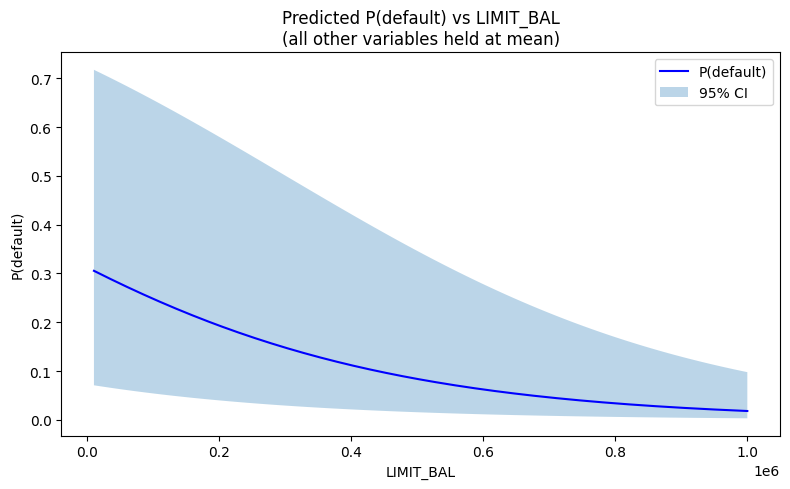

In [12]:
limit_range = np.linspace(
    train_tmp['LIMIT_BAL'].min(), train_tmp['LIMIT_BAL'].max(), 200)

# Hold all other features at their training means
X_at_means = pd.DataFrame(
    [train_tmp.drop(columns=['default']).mean()] * len(limit_range),
    columns=train_tmp.drop(columns=['default']).columns
)
X_at_means['LIMIT_BAL'] = limit_range

X_at_means_sm = sm.add_constant(X_at_means, has_constant='add')
pred_result   = result1.get_prediction(X_at_means_sm)
pred_df       = pred_result.summary_frame(alpha=0.05)

plt.figure(figsize=(8, 5))
plt.plot(limit_range, pred_df['predicted'], 'b-', label='P(default)')
plt.fill_between(limit_range,
                 pred_df['ci_lower'], pred_df['ci_upper'],
                 alpha=0.3, label='95% CI')
plt.xlabel('LIMIT_BAL')
plt.ylabel('P(default)')
plt.title('Predicted P(default) vs LIMIT_BAL\n(all other variables held at mean)')
plt.legend()
plt.tight_layout()
plt.show()


## A Visualization for Goodness-of-fit

Now let's go ahead and look at the ROC (Receiver Operating Characteristics) curve. This is really just a way to graph the confusion matrix. The idea is to use sensitivity = True Positives / (True Positives + False Negatives) and specificity = True Negatives / (True Negatives + False Positives) and plot the tradeoff. Depending on the scenario in question one may prefer one over the other, but in general one wants to maximize the AUC (area under the curve).


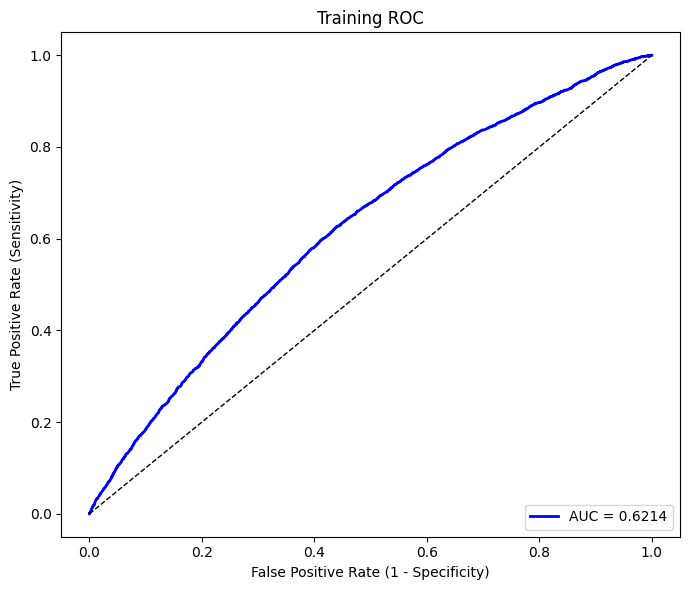

Training AUC: 0.6214


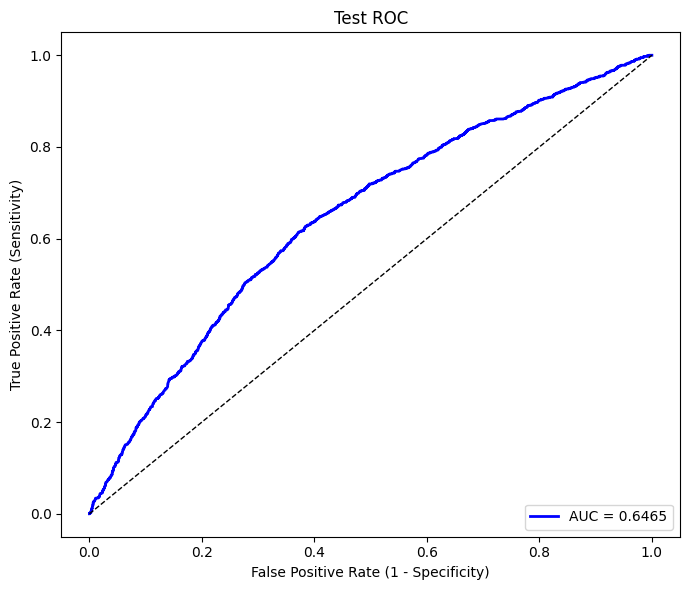


Test AUC: 0.6465


In [13]:
def plot_roc(y_true, y_score, title='ROC Curve'):
    """Plot ROC curve and return AUC. Equivalent to pROC::roc + plot."""
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    return roc_auc

# Training ROC — fittedvalues are predicted probabilities for training data
train_auc1 = plot_roc(train_tmp['default'], result1.fittedvalues, 'Training ROC')
print(f'Training AUC: {train_auc1:.4f}')

# Test ROC
X_test1_sm = sm.add_constant(test_tmp.drop(columns=['default']), has_constant='add')
test_pred1  = result1.predict(X_test1_sm)
test_auc1   = plot_roc(test_tmp['default'], test_pred1, 'Test ROC')
print(f'\nTest AUC: {test_auc1:.4f}')


## How did we do?

The simple classifier doesn't do too poorly. Training and test set performance are about the same, but we should be able to obtain better performance by including the remaining covariates. Add the covariates relating to past payment and bill balances using `.filter(regex=...)` and run the new regression model.


In [14]:
# Build train2: add PAY_* and BILL_* columns
train2 = pd.concat([
    train1,
    train_test.filter(regex='^PAY'),    # equivalent to select(starts_with('PAY'))
    train_test.filter(regex='^BILL'),   # equivalent to select(starts_with('BILL'))
], axis=1)

train_tmp, test_tmp = train_test_split(
    train2, test_size=0.2,
    stratify=train2['default'],
    random_state=2718281
)

X_train2_sm = sm.add_constant(train_tmp.drop(columns=['default']))
result2 = sm.Logit(train_tmp['default'], X_train2_sm).fit(disp=False, maxiter=200)
# Note: may produce a convergence / separation warning — equivalent to R's
# "glm.fit: fitted probabilities numerically 0 or 1 occurred"


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


How does our ROC improve by adding these covariates?

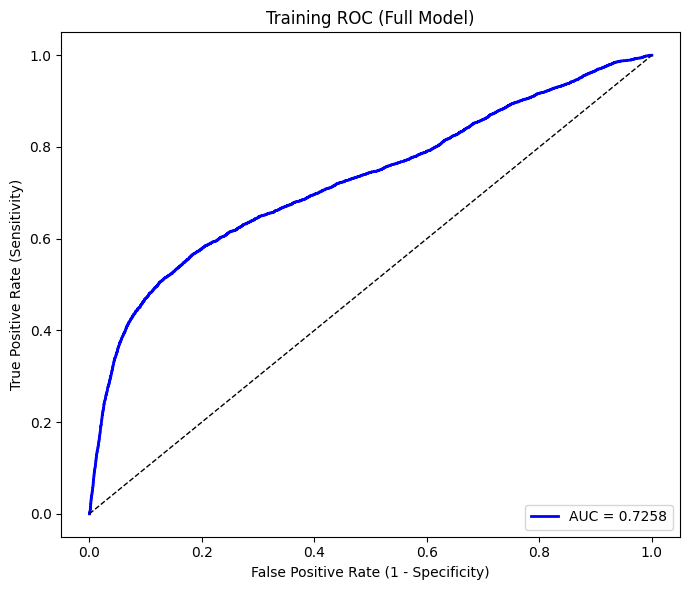

Training AUC: 0.7258


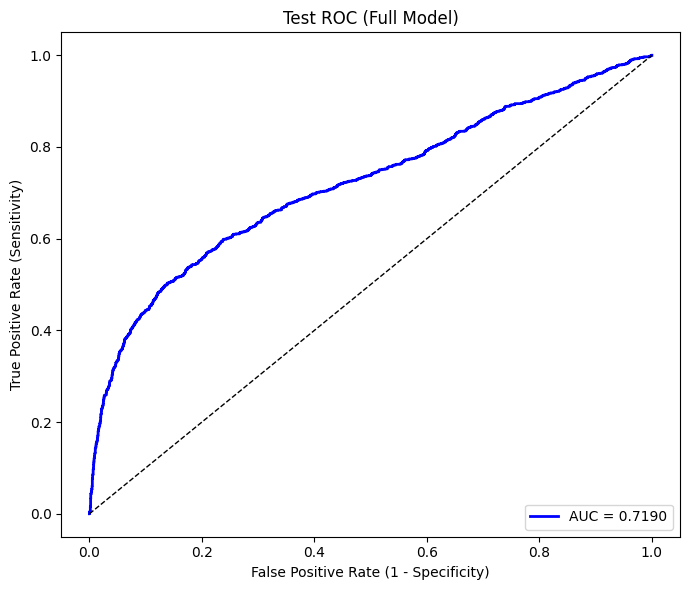


Test AUC: 0.7190


In [15]:
train_auc2 = plot_roc(
    train_tmp['default'], result2.fittedvalues, 'Training ROC (Full Model)')
print(f'Training AUC: {train_auc2:.4f}')

X_test2_sm = sm.add_constant(test_tmp.drop(columns=['default']), has_constant='add')
test_pred2  = result2.predict(X_test2_sm)
test_auc2   = plot_roc(test_tmp['default'], test_pred2, 'Test ROC (Full Model)')
print(f'\nTest AUC: {test_auc2:.4f}')


## Shrinkage in Nonlinear Models

The same penalty terms can be used in nonlinear models as they were in the linear case. Let's use Ridge on our model (much faster than Lasso).


In [34]:
# Standardize features — important for regularized logistic regression
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(train_tmp.drop(columns=['default']))
y_train   = train_tmp['default'].values
X_test_s  = scaler.transform(test_tmp.drop(columns=['default']))
y_test    = test_tmp['default'].values

# Cross-validate to find best regularization strength
# sklearn uses C = 1/lambda; large C = little regularization (small lambda)
# PERF: if slow reduce n_lambdas from 100 to 20 and reduce max_iter from 5000 to 500
n_lambdas = 100
cv_ridge = LogisticRegressionCV(
    cv=5, penalty='l2', solver='lbfgs', Cs=n_lambdas,
    max_iter=5000, random_state=2718281, n_jobs=-1,
)
#print(datetime.now().time())
cv_ridge.fit(X_train_s, y_train)
#print(datetime.now().time())
best_lambda = 1.0 / cv_ridge.C_[0]


100%|██████████| 50/50 [00:22<00:00,  2.18it/s]


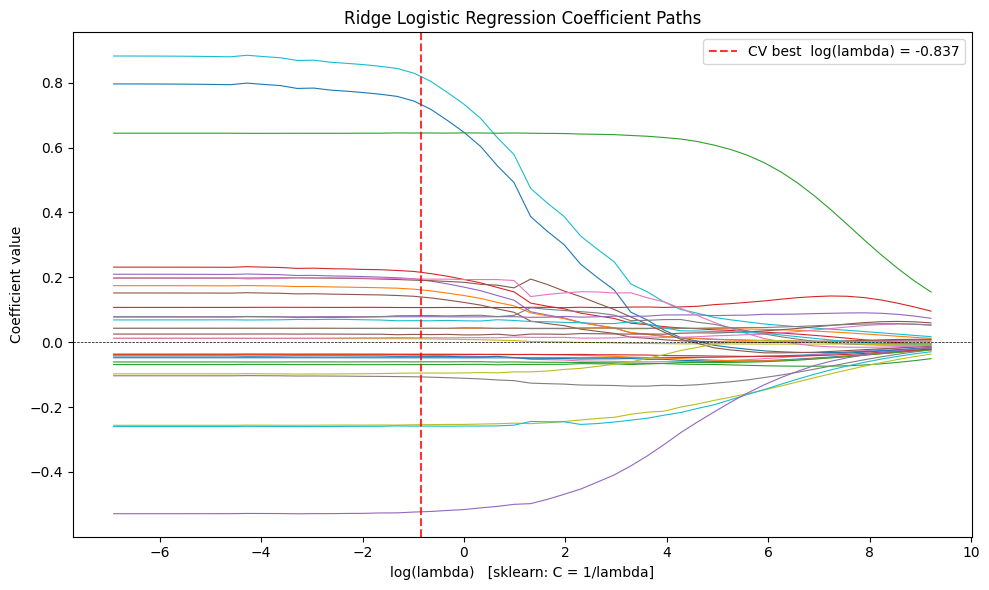

In [37]:
# Compute coefficient path across lambda values

#Cs_path = cv_ridge.Cs_ # this won't get smooth path
n_path_points = 50
Cs_path = np.logspace(3, -4, n_path_points)

coefs_path = []
for C in tqdm(Cs_path):
    lr = LogisticRegression(penalty='l2', solver='lbfgs', C=C,
                            max_iter=5000, random_state=2718281)
    lr.fit(X_train_s, y_train)
    coefs_path.append(lr.coef_[0])
coefs_path = np.array(coefs_path)

log_lambdas = np.log(1.0 / Cs_path)           # log(lambda) = -log(C)

plt.figure(figsize=(10, 6))
for j in range(coefs_path.shape[1]):
    plt.plot(log_lambdas, coefs_path[:, j], lw=0.8)
plt.axvline(np.log(best_lambda), color='red', ls='--', alpha=0.8,
            label=f'CV best  log(lambda) = {np.log(best_lambda):.3f}')
plt.xlabel('log(lambda)   [sklearn: C = 1/lambda]')
plt.ylabel('Coefficient value')
plt.title('Ridge Logistic Regression Coefficient Paths')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.legend()
plt.tight_layout()
plt.show()

*Prompt*: Plot the AUC of cv_ridge on using both X_train_s against y_train and X_test_s against y_test.

## Exercise

In this module we saw how to split data when the outcome variable is binary to ensure proper \
balance across the splits. We built a simple linear classifier using logistic regression and \
examined the individual significance of the parameters. In addition we showed how one can \
compute and display marginal effects of these covariates. We introduced the concept of ROC for \
goodness-of-fit and examined shrinkage. An interesting question to ask is what \
would happen if we subset the sample so that the default rate is much lower, i.e. the outcome \
variable is very imbalanced?

1. Subsample the data such that the default rate is much lower ($0.5\%$)
2. What happens when you run the logistic regression on this data?
3. Redo the Shrinkage regression on this subsample
4. What do you find?
